# CN7 2차 시도 — 선행 논문 기반 파생 변수로 재평가 (계획 4단계)

**지금까지 (보고서 1~3단계)**
- 1단계: `CN7.ipynb`(데이터 진단·정제·이상탐지)와 `CN7_models.ipynb`(36종 모델 비교)에서 공정 값 23개로 이상탐지·지도학습을 샷 묶음 교차검증으로 비교했다.
- 2단계 판정 **실패**: CN7: 36종 모두 무작위(0.232)·쌍 순서 규칙(0.304)은 크게 넘지만 **샷 순서 기준선(0.766)을 넘지 못함**. 최고는 LightGBM (공정 값 + pair_pos) 0.745 ± 0.201. 튜닝·앙상블·불균형 샘플링도 효과가 없어, 원인을 **모델이 아니라 입력 정보 부족**으로 판단했다.
- 3단계: 신규 데이터(원본 1차 가공 데이터의 제품명·시각)는 확보하지 못해, **기존 23개 공정 값으로 만들 수 있는 파생 변수**를 선행 논문을 참고해 설계했다 (보고서 표 5).

**이 노트북 (4단계)**: 1차와 **같은 분할·지표·기준선**으로, 1차 상위 계열(부스팅·랜덤포레스트)과 해석용 로지스틱을 `공정 값 23 + 파생 변수`로 다시 학습해 판정한다.

**성공 기준 (재시도 전 확정, 보고서 4단계)** — 판정용 평가 **E2 불량 시기 안** (샷 0~마지막 불량 샷, 121부품 · 불량 17)에서
1. PR-AUC가 기준선과 1차 최고 모델을 **fold 간 표준편차 이상** 넘을 것. 기준선 = **샷 순서** (0.766 ± 0.184), 1차 최고 = **LightGBM (공정 값 + pair_pos)** (0.745 ± 0.201)
2. 파생 변수의 추가 기여가 **조건부 순열검정 p < 0.05**일 것

| 섹션 | 내용 | 보고서 연결 |
|---|---|---|
| 1 | 설정·데이터 (1차와 같은 `model_zoo.py`) | — |
| 2 | 파생 변수 만들기 + 누수 점검 | 3단계 표 5 |
| 3 | 파생 변수 탐색: 불량 vs 양품, 시간 흐름과의 관계 | 제3장 영향요인 |
| 4 | 재평가: 8개 모델 × 피처 조합 (E2 판정용 / E1 참고) | 4단계 |
| 5 | 추가 기여 검정 (조건부 순열) | 성공 기준 ② |
| 6 | 판정 | 표 6 |
| 7 | 결론과 5단계 연결 | 5단계 · 제4장 |

## 1. 설정 · 데이터

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, spearmanr

import model_zoo as mz

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if f in installed_fonts), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 250)

C_MAIN, C_SUB, C_ALT, C_OK = '#2a78d6', '#eb6834', '#8c6bb1', '#3a9a5b'
C_INK, C_GRID = '#52514e', '#e6e5e0'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': C_GRID, 'axes.labelcolor': C_INK,
    'xtick.color': C_INK, 'ytick.color': C_INK,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.6,
    'axes.titlesize': 10,
})

SEED = mz.SEED  # 42, 1차와 같음
TARGET = mz.TARGET
TABLES, FIGS = Path('outputs/tables'), Path('outputs/figures')
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
RUN = False  # True: 재평가·순열검정을 다시 계산 (16코어 기준 약 8분). False: 저장된 결과(outputs/tables/derived_*.csv) 사용

ev, feats = mz.load_evalset()  # 1차와 같은 labeled + shot_id(샷 번호, 시간 순) + pair_pos(쌍 순서)
print(f'부품 {len(ev):,} · 샷 {ev["shot_id"].nunique():,} · 불량 {ev[TARGET].sum()} · 공정 값 {len(feats)}개')

부품 1,211 · 샷 606 · 불량 17 · 공정 값 23개


## 2. 파생 변수 만들기

### 2-1. 설계 (보고서 표 5)

| 참고 논문 | 논문의 핵심 | 이 데이터에 적용한 파생 변수 | 개수 |
|---|---|---|---|
| Ke & Huang (2021) [1] | 압력 곡선의 피크·적분·보압 강하 등 품질 지표로 품질 등급 분류 | **압력 지표**: 최대 사출압 − 전환압, 최대 배압 − 평균 배압 | 2 |
| Gim & Rhee (2021) [2] | 캐비티 압력 곡선의 상태점(전환·피크·보압 종료·냉각 종료) 시간·압력이 부품 중량에 가장 큰 영향 | **시간 구성**: 충전 − 사출 시간, 가소화 − 사이클 시간, 사이클 − 사출 − 형체 시간(냉각·취출 구간 근사) | 3 |
| Párizs 외 (2022) [3] | 압력 곡선의 구간 적분·최대값·기울기 등 파생 특징 19개 + 특징 선택 | **계량**: 가소화 위치 − 쿠션 위치 (1회 사출 스트로크 근사) | 1 |
| 공정 지식 | 실린더 구간별 온도 구배, 금형 온도 채널 간 차이는 용융·냉각 균일성과 관련 | **온도 구배**: 배럴 인접 구간 차 5개, 배럴 최고 − 최저, 금형 온도 3 − 4 | 7 |
| Lughofer & Pichler (2024) [4] | 공정 값의 시계열 추세 특징으로 품질 저하를 사전에 예측 | **샷 간 변동** (핵심 8개 변수): 이전 샷 대비 변화량(Δ1), 최근 5·10샷 이동평균(MA)·이동표준편차(SD), 과거 10샷 이동 중앙값 대비 편차 + 23개 전체의 평균 \|Δ1\|, 평균 SD10 | 8 × 6 + 2 = 50 |

- **핵심 8개 변수** (샷 간 변동용, 결과를 보기 전에 공정 지식으로 고정): 압력 2(최대 사출압, 전환압) · 계량 2(쿠션 위치, 가소화 위치) · 시간 3(사출, 가소화, 사이클) · 금형 온도 1(금형 온도 3). 논문 [1]~[3]이 품질과 연결한 압력·계량·시간 상태와, 금형 냉각 상태를 대표한다. 23개 모두에 적용하면 샷 간 변수만 138개가 되어 불량 17~25개 규모에 비해 너무 많다.

**설계 원칙** (보고서 3단계와 같음)
1. 검사 전에 알 수 있는 값만 사용한다. 이동 통계는 **현재 샷까지**(현재 포함)의 값만, 이동 중앙값 편차는 **과거 샷만** 쓴다. 다음 샷 값은 쓰지 않는다 → 2-3에서 코드로 확인.
2. 샷 단위로 계산해 같은 샷의 두 부품에 똑같이 부여한다.
3. 표준화는 학습 fold 안에서만 한다 (`model_zoo`의 파이프라인. 트리 계열은 표준화 불필요).
4. 이동 통계 창 크기(5·10샷)는 결과를 보기 전에 고정했다.

**데이터 제약 — 비율 대신 차이**
- 제공 데이터는 파일별로 **표준화(z값)** 되어 있고 원래 평균·표준편차를 알 수 없다. 그래서 논문의 비율 지표(전환압 / 최대 사출압, 충전 시간 / 사출 시간 등)는 계산할 수 없다. z값의 비율은 분모가 0 근처일 때 발산해 의미가 없다.
- 대신 **z값의 차이**를 쓴다. "각 변수가 평소보다 얼마나 벗어났는지의 차이"라서, 두 값이 함께 움직이면 0, 따로 움직이면 커진다.
- **예상되는 한계**: 샷 내 파생 13개는 모두 기존 23개의 **선형 결합**이다. 로지스틱 같은 선형 모델에는 새 정보가 아니고, 트리 계열에만 사선 방향 분할이라는 새 표현을 준다. 실제로 새 정보를 더하는 것은 **이웃 샷 값을 쓰는 샷 간 변동**뿐이다.
- 샷 간 변동은 시간 정보를 강하게 담는다(이동평균 = 최근 공정 수준). 그래서 1차와 같은 **샷 순서 기준선**과 **조건부 순열검정**(5-2)으로 시간 이상의 정보인지 판정한다.

### 2-2. 계산

In [2]:
KEY_VARS = ['Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Cushion_Position', 'Plasticizing_Position',
            'Injection_Time', 'Plasticizing_Time', 'Cycle_Time', 'Mold_Temperature_3']
BARRELS = [f'Barrel_Temperature_{i}' for i in range(1, 7)]
WINDOWS = (5, 10)


def within_shot(s):
    """샷 내 파생 (논문 [1]~[3] + 공정 지식). z값이라 비율 대신 차이"""
    d = pd.DataFrame(index=s.index)
    d['압력_최대사출-전환'] = s['Max_Injection_Pressure'] - s['Max_Switch_Over_Pressure']       # [1]
    d['압력_최대배압-평균배압'] = s['Max_Back_Pressure'] - s['Average_Back_Pressure']          # [1]
    d['시간_충전-사출'] = s['Filling_Time'] - s['Injection_Time']                             # [2]
    d['시간_가소화-사이클'] = s['Plasticizing_Time'] - s['Cycle_Time']                        # [2]
    d['시간_냉각취출근사'] = s['Cycle_Time'] - s['Injection_Time'] - s['Clamp_Close_Time']   # [2]
    d['계량_가소화위치-쿠션'] = s['Plasticizing_Position'] - s['Cushion_Position']            # [3]
    for a, b in zip(BARRELS[:-1], BARRELS[1:]):                                              # 공정 지식
        d[f'온도_배럴{a[-1]}-{b[-1]}'] = s[a] - s[b]
    d['온도_배럴최고-최저'] = s[BARRELS].max(axis=1) - s[BARRELS].min(axis=1)
    d['온도_금형3-4'] = s['Mold_Temperature_3'] - s['Mold_Temperature_4']
    return d


def between_shot(s):
    """샷 간 변동 (논문 [4]). s는 샷 순서로 정렬된 샷 단위 표. 현재 샷까지의 값만 사용"""
    d = {}
    for v in KEY_VARS:
        x = s[v]
        d[f'{v}_Δ1'] = x.diff().fillna(0)                                   # 이전 샷 대비 변화량
        for w in WINDOWS:
            r = x.rolling(w, min_periods=1)                                  # 현재 샷 포함 최근 w샷
            d[f'{v}_MA{w}'] = r.mean()
            d[f'{v}_SD{w}'] = r.std().fillna(0)
        d[f'{v}_중앙값10편차'] = (x - x.shift(1).rolling(10, min_periods=1).median()).fillna(0)  # 과거 10샷만
    d['전체_평균|Δ1|'] = s[feats].diff().abs().mean(axis=1).fillna(0)
    d['전체_평균SD10'] = s[feats].rolling(10, min_periods=2).std().mean(axis=1).fillna(0)
    return pd.DataFrame(d, index=s.index)


def derive(shots):
    return pd.concat([within_shot(shots), between_shot(shots)], axis=1)


shots = ev.groupby('shot_id')[feats].first().sort_index()   # 샷 단위 (같은 샷의 두 부품은 공정 값이 같음)
D = derive(shots)
WITHIN = list(within_shot(shots).columns)
BETWEEN = [c for c in D.columns if c not in WITHIN]
DERIVED = WITHIN + BETWEEN

# 부품 단위로 붙이기. 열 순서 = 공정 값 23 → pair_pos → 파생 (model_zoo의 샷 묶음은 앞 23열로 판단)
evd = pd.concat([ev.reset_index(drop=True), D.loc[ev['shot_id']].reset_index(drop=True)], axis=1)
print(f'샷 내 파생 {len(WITHIN)}개 + 샷 간 변동 {len(BETWEEN)}개 = {len(DERIVED)}개 → 입력 최대 {len(feats) + 1 + len(DERIVED)}열')
pd.DataFrame({'구분': ['샷 내'] * len(WITHIN) + ['샷 간'] * len(BETWEEN), '변수': DERIVED}).groupby('구분')['변수'].apply(lambda s: ', '.join(s[:14]) + (' …' if len(s) > 14 else ''))

샷 내 파생 13개 + 샷 간 변동 50개 = 63개 → 입력 최대 87열


구분
샷 간    Max_Injection_Pressure_Δ1, Max_Injection_Press...
샷 내    압력_최대사출-전환, 압력_최대배압-평균배압, 시간_충전-사출, 시간_가소화-사이클...
Name: 변수, dtype: str

### 2-3. 누수 점검

1. **미래 샷 값을 쓰지 않는가**: 중간 샷 이후의 공정 값을 무작위로 크게 바꿔도, 그 샷까지의 파생 변수가 그대로여야 한다.
2. **같은 샷의 두 부품이 같은 값인가**: 파생 변수가 샷 단위로 부여됐는지 확인한다.

In [3]:
rng = np.random.default_rng(SEED)
for t in [shots.index[10], shots.index[len(shots) // 2], shots.index[-2]]:
    s2 = shots.copy()
    fut = s2.index > t
    s2.loc[fut] = s2.loc[fut].values + rng.normal(0, 5, size=(fut.sum(), len(feats)))
    same = np.allclose(derive(shots).loc[:t].values, derive(s2).loc[:t].values)
    print(f'샷 {t} 이후 값을 바꿨을 때 샷 0~{t} 파생 변수 동일: {same}')
    assert same

n_diff = evd.groupby('shot_id')[DERIVED].nunique().gt(1).sum().sum()
print('같은 샷 안에서 값이 다른 파생 변수 칸 수:', n_diff)
assert n_diff == 0

샷 10 이후 값을 바꿨을 때 샷 0~10 파생 변수 동일: True
샷 303 이후 값을 바꿨을 때 샷 0~303 파생 변수 동일: True
샷 604 이후 값을 바꿨을 때 샷 0~604 파생 변수 동일: True
같은 샷 안에서 값이 다른 파생 변수 칸 수: 0


## 3. 파생 변수 탐색

판정용 평가(E2) 데이터에서 파생 변수 하나씩 불량 샷과 양품 샷의 차이를 본다. 모델 판정 전에, 어떤 신호가 있는지와 그 신호가 **시간 흐름**과 얼마나 겹치는지 확인하는 단계다.
- 단위: 샷 (같은 샷의 두 부품은 값이 같으므로 부품 단위로 세면 표본이 부풀려진다). 샷 중 한 부품이라도 불량이면 불량 샷.
- 차이 = (불량 평균 − 양품 평균) / 양품 표준편차 (σ 단위), 검정 = Mann-Whitney, 다중검정 보정 = Benjamini-Hochberg q
- 샷 순서 상관 = Spearman ρ (|ρ|가 크면 그 변수는 시간 흐름을 담고 있음)

In [4]:
last_ng = evd.loc[evd[mz.TARGET] == 1, 'shot_id'].max()
E2_NAME = f'E2 불량 시기 안 (샷 0~{last_ng})'
e2 = evd[evd['shot_id'] <= last_ng].reset_index(drop=True)
print(E2_NAME, f'부품 {len(e2)} · 샷 {e2["shot_id"].nunique()} · 불량 {e2[TARGET].sum()}')


def bh(p):
    p = np.asarray(p)
    o = np.argsort(p)
    q = p[o] * len(p) / np.arange(1, len(p) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[o] = np.minimum(q, 1)
    return out


def univariate(ev_e, cols):
    sh = ev_e.groupby('shot_id').agg({**{c: 'first' for c in cols}, TARGET: 'max'})
    y = sh[TARGET].values
    rows = []
    for c in cols:
        x = sh[c].values
        sd = x[y == 0].std()
        rows.append({'변수': c, '구분': '공정 값' if c in feats else ('샷 내 파생' if c in WITHIN else '샷 간 변동'),
                     '차이(σ)': (x[y == 1].mean() - x[y == 0].mean()) / sd if sd > 0 else np.nan,
                     'p': mannwhitneyu(x[y == 1], x[y == 0]).pvalue if np.ptp(x) > 0 else 1.0,
                     '샷 순서 ρ': spearmanr(sh.index, x).statistic if np.ptp(x) > 0 else np.nan})
    t = pd.DataFrame(rows)
    t['q'] = bh(t['p'])
    return t.sort_values('p').reset_index(drop=True)


uni = univariate(e2, feats + DERIVED)
uni.to_csv(TABLES / 'derived_univariate.csv', index=False, encoding='utf-8-sig')
print('q < 0.05 변수 수:', uni[uni['q'] < 0.05].groupby('구분').size().to_dict() or 0)
uni.head(15).round(3)

E2 불량 시기 안 (샷 0~60) 부품 121 · 샷 61 · 불량 17


q < 0.05 변수 수: {'샷 간 변동': 3}


,변수,구분,차이(σ),p,샷 순서 ρ,q
0,Plasticizing_Time_MA10,샷 간 변동,1.343,0.000,0.608,0.001
1,Plasticizing_Time_MA5,샷 간 변동,1.379,0.000,0.547,0.001
2,Mold_Temperature_3_MA10,샷 간 변동,1.174,0.001,0.789,0.024
3,Injection_Time_MA10,샷 간 변동,-1.796,0.003,-0.708,0.058
4,Plasticizing_Time,공정 값,0.883,0.004,0.449,0.074
5,Hopper_Temperature,공정 값,0.936,0.007,0.165,0.106
6,Plasticizing_Position_SD10,샷 간 변동,-0.635,0.009,0.004,0.109
7,Mold_Temperature_3_MA5,샷 간 변동,0.767,0.011,0.752,0.116
8,시간_가소화-사이클,샷 내 파생,0.498,0.016,0.333,0.143
9,Cycle_Time_MA10,샷 간 변동,-0.597,0.017,-0.189,0.143


→ q < 0.05인 변수는 **샷 간 변동 3개뿐이고, 모두 이동평균**이다: 가소화 시간 MA10·MA5(불량 샷에서 +1.3σ·+1.4σ), 금형 온도 3 MA10(+1.2σ).
→ 이 셋은 샷 순서와의 상관도 크다(ρ 0.55~0.79). 불량 시기 안에서도 불량은 뒤쪽 샷에 몰려 있어서, "최근 가소화 시간·금형 온도가 서서히 올랐다"는 **추세 = 시간 흐름**을 담고 있을 가능성이 크다 → 4-5와 5장에서 확인한다.
→ 샷 내 파생은 가장 강한 `시간_가소화-사이클`도 0.50σ(q = 0.14)로 유의하지 않다.

## 4. 재평가 — 1차와 같은 분할 · 지표 · 기준선

- **분할**: `shot_id` 묶음 층화 5-fold × 10회 (50 fold). 1차와 같은 시드라 **fold가 1차와 완전히 같다** → 모델별로 fold를 짝지어 비교할 수 있다.
- **모델 (8종, 결과를 보기 전에 고정)**: 1차 상위 계열 — 랜덤포레스트, 엑스트라트리, GradientBoosting, HistGradientBoosting, XGBoost, LightGBM, CatBoost — 와 해석용 로지스틱 L2. 설정은 `model_zoo.py`의 1차 설정 그대로다. 튜닝·앙상블은 1차에서 효과가 없어 제외했다.
- **피처 조합**: 1차 피처(`공정 값 23` / `+ pair_pos`) 각각에 `+ 샷 내 파생`, `+ 샷 간 변동`, `+ 파생 전체`를 붙인다. 파생 없는 조합은 **1차 재현 확인**용이다 (1차 수치와 같아야 함).
- **E1 전체 기간**은 참고용이라 `파생 없음 / 파생 전체`만 계산한다.

In [5]:
sup = mz.supervised_models()
MODEL_NAMES = ['로지스틱 L2', '랜덤포레스트', '엑스트라트리', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
MODELS = {k: (sup[k][0], sup[k][1], False) for k in MODEL_NAMES}
FAMILY = {k: sup[k][1] for k in MODEL_NAMES}
ADD = {'': [], ' + 샷 내 파생': WITHIN, ' + 샷 간 변동': BETWEEN, ' + 파생 전체': DERIVED}
E2_BASES = {'공정 값 23': feats, '공정 값 23 + pair_pos': feats + ['pair_pos']}
E1_BASES = {'공정 값 23': feats, '공정 값 23 + pair_pos': feats + ['pair_pos']}
E1_NAME = 'E1 전체 기간'
PLAN = {E2_NAME: (e2, {b + a: cols + extra for b, cols in E2_BASES.items() for a, extra in ADD.items()}),
        E1_NAME: (evd, {b + a: cols + extra for b, cols in E1_BASES.items() for a, extra in ADD.items() if a in ('', ' + 파생 전체')})}


def run_eval(e_name, ev_e, feature_sets):
    y, g = ev_e[TARGET].values, ev_e['shot_id'].values
    splits = mz.make_splits(y, g)
    base, b_scores = mz.baseline_rows(ev_e, y, splits)
    folds = [base.assign(eval=e_name, features='-', family='기준선')]
    ins = [mz.inspection_rates(b_scores, base['model'].unique(), y, splits).assign(eval=e_name, features='-', family='기준선')]
    for f_name, cols in feature_sets.items():
        t = time.time()
        r, scores = mz.evaluate_models(MODELS, ev_e[cols].values.astype(float), y, g, splits)
        folds.append(r.assign(eval=e_name, features=f_name, family=r['model'].map(FAMILY)))
        i = mz.inspection_rates(scores, r['model'].unique(), y, splits)
        ins.append(i.assign(eval=e_name, features=f_name, family=i['model'].map(FAMILY)))
        print(f'{e_name} / {f_name} ({len(cols)}열): {time.time() - t:.0f}s', flush=True)
    return pd.concat(folds, ignore_index=True), pd.concat(ins, ignore_index=True)


if RUN:
    out = [run_eval(e, ev_e, fs) for e, (ev_e, fs) in PLAN.items()]
    folds = pd.concat([o[0] for o in out], ignore_index=True)
    inspect = pd.concat([o[1] for o in out], ignore_index=True)
    keys = ['eval', 'features', 'family', 'model']
    g, gi = folds.groupby(keys, sort=False), inspect.groupby(keys, sort=False)
    summary = (g[mz.METRICS + ['threshold']].mean().add_suffix('_mean').join(g[mz.METRICS].std().add_suffix('_std'))
               .join(gi[mz.INSPECT].mean().add_suffix('_mean')).join(gi[mz.INSPECT].std().add_suffix('_std'))).reset_index()
    folds.to_csv(TABLES / 'derived_folds.csv', index=False, encoding='utf-8-sig')
    summary.to_csv(TABLES / 'derived_summary.csv', index=False, encoding='utf-8-sig')
else:
    folds = pd.read_csv(TABLES / 'derived_folds.csv')
    summary = pd.read_csv(TABLES / 'derived_summary.csv')

### 4-1. 1차 재현 확인

파생 변수 없는 조합은 1차(`outputs/tables/model_summary.csv`)와 같은 모델·fold라 PR-AUC가 같아야 한다.

In [6]:
first = pd.read_csv(TABLES / 'model_summary.csv')
chk = (summary[summary['features'].isin(list(E2_BASES) + list(E1_BASES))]
       .merge(first, on=['eval', 'features', 'model'], suffixes=('', '_1차'))[['eval', 'features', 'model', 'PR-AUC_mean', 'PR-AUC_mean_1차']])
chk['차이'] = (chk['PR-AUC_mean'] - chk['PR-AUC_mean_1차']).abs()
print(f'비교 {len(chk)}행 · 최대 차이 {chk["차이"].max():.2e}')
assert len(chk) > 0 and chk['차이'].max() < 1e-9

비교 32행 · 최대 차이 0.00e+00


### 4-2. E2 판정용 결과

값은 50 fold 평균 ± 표준편차 (검사율@재현율은 반복 10회 평균). 표 아래쪽 `Δ vs 파생 없음`은 **같은 모델·같은 fold**에서 파생 변수를 넣기 전과 뒤의 PR-AUC 차이다 (짝지은 비교라 모델 간 비교보다 잡음이 작다).

In [7]:
MAIN = ['PR-AUC', 'Recall@10%', 'Recall@20%', 'Recall@30%']
COST = ['검사율@재현율0.9', '검사율@재현율1']


def table(e_name, features=None, top=None):
    d = summary[summary['eval'] == e_name]
    if features is not None:
        d = d[d['features'].isin(features + ['-'])]
    d = d.sort_values('PR-AUC_mean', ascending=False)
    out = pd.DataFrame({'피처': d['features'].values, '모델': d['model'].values})
    for m in MAIN:
        out[m] = (d[f'{m}_mean'].map('{:.3f}'.format) + ' ± ' + d[f'{m}_std'].map('{:.3f}'.format)).values
    for m in COST:
        out[m] = d[f'{m}_mean'].map('{:.0%}'.format).values
    return out.head(top) if top else out


def prauc_grid(e_name):
    d = summary[(summary['eval'] == e_name) & (summary['family'] != '기준선')]
    t = d.pivot(index='model', columns='features', values='PR-AUC_mean')
    cols = [c for c in PLAN[e_name][1] if c in t.columns]
    return t.loc[MODEL_NAMES, cols]


def paired_delta(e_name):
    """같은 모델·같은 fold에서 (파생 추가 − 파생 없음) PR-AUC"""
    f = folds[(folds['eval'] == e_name) & (folds['family'] != '기준선')]
    rows = []
    bases = E2_BASES if e_name == E2_NAME else E1_BASES
    for b in bases:
        base = f[f['features'] == b].set_index(['model', 'fold'])['PR-AUC']
        for a in [k for k in ADD if k and b + k in f['features'].unique()]:
            add = f[f['features'] == b + a].set_index(['model', 'fold'])['PR-AUC']
            dlt = (add - base).dropna()
            for m in MODEL_NAMES:
                x = dlt.loc[m]
                rows.append({'기본 피처': b, '추가': a.strip(' +'), '모델': m, 'Δ PR-AUC 평균': x.mean(), 'Δ 표준편차': x.std(),
                             '개선 fold 비율': (x > 0).mean()})
    return pd.DataFrame(rows)


print(E2_NAME, '— PR-AUC (50 fold 평균), 행 = 모델, 열 = 피처 조합')
display(prauc_grid(E2_NAME).round(3))
base_rows = summary[(summary['eval'] == E2_NAME) & (summary['family'] == '기준선')].set_index('model')['PR-AUC_mean'].round(3)
print('기준선:', base_rows.to_dict())

E2 불량 시기 안 (샷 0~60) — PR-AUC (50 fold 평균), 행 = 모델, 열 = 피처 조합


features,공정 값 23,공정 값 23 + 샷 내 파생,공정 값 23 + 샷 간 변동,공정 값 23 + 파생 전체,공정 값 23 + pair_pos,공정 값 23 + pair_pos + 샷 내 파생,공정 값 23 + pair_pos + 샷 간 변동,공정 값 23 + pair_pos + 파생 전체
model,,,,,,,,
로지스틱 L2,0.559,0.553,0.696,0.652,0.642,0.625,0.784,0.761
랜덤포레스트,0.581,0.520,0.708,0.708,0.669,0.561,0.810,0.806
엑스트라트리,0.546,0.517,0.723,0.723,0.620,0.577,0.857,0.862
GradientBoosting,0.550,0.515,0.687,0.674,0.656,0.574,0.812,0.806
HistGradientBoosting,0.534,0.481,0.671,0.666,0.617,0.589,0.824,0.831
XGBoost,0.568,0.433,0.694,0.661,0.674,0.538,0.843,0.840
LightGBM,0.641,0.537,0.725,0.708,0.745,0.666,0.873,0.874
CatBoost,0.566,0.544,0.724,0.714,0.663,0.605,0.840,0.856


기준선: {'[기준] 무작위': 0.232, '[기준] 쌍 순서 규칙': 0.304, '[기준] 샷 순서': 0.766}


In [8]:
table(E2_NAME, top=15)

,피처,모델,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1
0,공정 값 23 + pair_pos + 파생 전체,LightGBM,0.874 ± 0.146,0.773 ± 0.144,0.872 ± 0.169,0.877 ± 0.169,54%,66%
1,공정 값 23 + pair_pos + 샷 간 변동,LightGBM,0.873 ± 0.147,0.767 ± 0.156,0.872 ± 0.169,0.882 ± 0.168,47%,63%
2,공정 값 23 + pair_pos + 파생 전체,엑스트라트리,0.862 ± 0.170,0.762 ± 0.161,0.872 ± 0.169,0.877 ± 0.169,67%,89%
3,공정 값 23 + pair_pos + 샷 간 변동,엑스트라트리,0.857 ± 0.180,0.768 ± 0.163,0.877 ± 0.169,0.877 ± 0.169,66%,88%
4,공정 값 23 + pair_pos + 파생 전체,CatBoost,0.856 ± 0.159,0.750 ± 0.182,0.855 ± 0.176,0.883 ± 0.152,46%,70%
5,공정 값 23 + pair_pos + 샷 간 변동,XGBoost,0.843 ± 0.166,0.737 ± 0.175,0.860 ± 0.170,0.872 ± 0.169,53%,66%
6,공정 값 23 + pair_pos + 파생 전체,XGBoost,0.840 ± 0.164,0.730 ± 0.184,0.848 ± 0.177,0.877 ± 0.169,52%,66%
7,공정 값 23 + pair_pos + 샷 간 변동,CatBoost,0.840 ± 0.151,0.737 ± 0.154,0.857 ± 0.168,0.890 ± 0.150,50%,71%
8,공정 값 23 + pair_pos + 파생 전체,HistGradientBoosting,0.831 ± 0.168,0.720 ± 0.170,0.837 ± 0.182,0.863 ± 0.184,59%,79%
9,공정 값 23 + pair_pos + 샷 간 변동,HistGradientBoosting,0.824 ± 0.152,0.685 ± 0.176,0.848 ± 0.170,0.877 ± 0.169,58%,74%


In [9]:
delta_e2 = paired_delta(E2_NAME)
delta_e2.to_csv(TABLES / 'derived_paired_delta.csv', index=False, encoding='utf-8-sig')
delta_e2.pivot_table(index='모델', columns=['기본 피처', '추가'], values='Δ PR-AUC 평균', sort=False).loc[MODEL_NAMES].round(3)

기본 피처                공정 값 23               공정 값 23 + pair_pos              
추가                    샷 내 파생 샷 간 변동  파생 전체             샷 내 파생 샷 간 변동  파생 전체
모델                                                                         
로지스틱 L2               -0.007  0.136  0.093             -0.017  0.142  0.119
랜덤포레스트                -0.061  0.127  0.126             -0.108  0.141  0.136
엑스트라트리                -0.029  0.177  0.177             -0.043  0.237  0.242
GradientBoosting      -0.036  0.137  0.123             -0.083  0.156  0.150
HistGradientBoosting  -0.053  0.137  0.132             -0.029  0.206  0.214
XGBoost               -0.135  0.126  0.093             -0.136  0.169  0.166
LightGBM              -0.104  0.084  0.067             -0.079  0.128  0.129
CatBoost              -0.022  0.158  0.148             -0.058  0.177  0.193

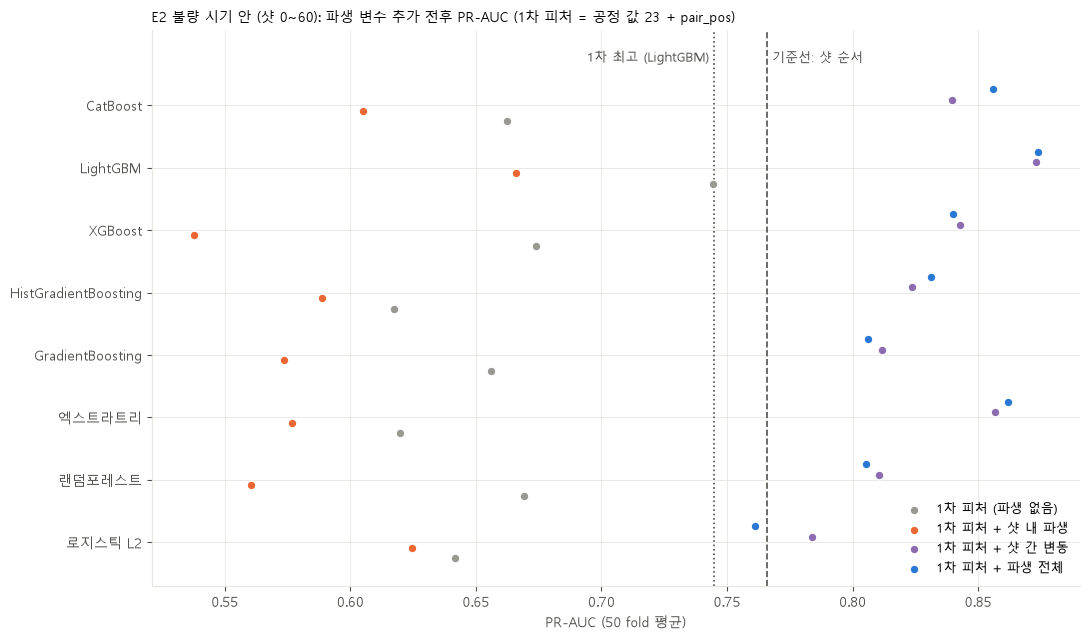

In [10]:
fig, ax = plt.subplots(figsize=(11, 6.5))
fs = [f for f in PLAN[E2_NAME][1] if f.startswith('공정 값 23 + pair_pos')]
colors = dict(zip(fs, ['#9a9893', C_SUB, C_ALT, C_MAIN]))
yy = np.arange(len(MODEL_NAMES))
grid = prauc_grid(E2_NAME)
for k, f in enumerate(fs):
    ax.scatter(grid.loc[MODEL_NAMES, f], yy + (k - 1.5) * 0.17, s=40, color=colors[f], edgecolor='white', linewidth=1, zorder=3,
               label=f.replace('공정 값 23 + pair_pos', '1차 피처') if f != '공정 값 23 + pair_pos' else '1차 피처 (파생 없음)')
first_model, first_feat, first_mean, first_std = ('LightGBM', '공정 값 23 + pair_pos', 0.745, 0.201)
vlines = sorted([(base_rows['[기준] 샷 순서'], '[기준] 샷 순서'.replace('[기준] ', '기준선: '), '--'), (first_mean, f'1차 최고 ({first_model})', ':')])
for (x, lab, ls), ha in zip(vlines, ['right', 'left']):  # 두 선이 가까워도 라벨이 겹치지 않게 왼쪽 선은 왼쪽에, 오른쪽 선은 오른쪽에
    ax.axvline(x, color=C_INK, linestyle=ls, linewidth=1.2)
    ax.text(x, len(MODEL_NAMES) - 0.35, f' {lab} ' , color=C_INK, fontsize=9, va='bottom', ha=ha)
ax.set_yticks(yy, MODEL_NAMES)
ax.set_ylim(-0.7, len(MODEL_NAMES) + 0.2)
ax.set_xlabel('PR-AUC (50 fold 평균)')
ax.set_title(f'{E2_NAME}: 파생 변수 추가 전후 PR-AUC (1차 피처 = 공정 값 23 + pair_pos)', loc='left')
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'derived_prauc.png', dpi=150, bbox_inches='tight')
plt.show()

**E2 결과 읽기**
- **샷 간 변동**을 넣으면 8개 모델 모두 PR-AUC가 크게 오른다. 같은 fold끼리 짝지은 Δ는 +0.13~+0.24(`pair_pos` 포함 기준)이다. 최고는 **LightGBM (공정 값 + pair_pos + 파생 전체) 0.874 ± 0.146**이다. 평균으로는 처음으로 1차 최고(0.745)와 샷 순서 기준선(0.766)을 넘는다.
- **샷 내 파생**은 8개 모델 모두에서 오히려 성능을 낮춘다 (Δ −0.01~−0.14). 2-1에서 예상한 대로 기존 23개의 선형 결합이라 새 정보가 없고, 불량 17개 규모에서 입력 수만 늘어 잡음이 커졌다.
- **손익 분석용 지표는 다르게 움직인다.** 최고 모델의 Recall@10%는 0.61 → 0.77로 올랐지만, 검사율@재현율0.9는 **38% → 54%로 나빠졌다** (샷 순서 29%). 잡기 쉬운 불량은 순위를 더 올리지만, 잡기 어려운 불량 1~2개는 오히려 더 아래로 내린다.

### 4-3. E1 전체 기간 (참고)

In [11]:
display(prauc_grid(E1_NAME).round(3))
print('기준선:', summary[(summary['eval'] == E1_NAME) & (summary['family'] == '기준선')].set_index('model')['PR-AUC_mean'].round(3).to_dict())
table(E1_NAME, top=10)

features,공정 값 23,공정 값 23 + 파생 전체,공정 값 23 + pair_pos,공정 값 23 + pair_pos + 파생 전체
model,,,,
로지스틱 L2,0.474,0.455,0.540,0.521
랜덤포레스트,0.446,0.532,0.490,0.640
엑스트라트리,0.455,0.669,0.521,0.808
GradientBoosting,0.420,0.561,0.456,0.647
HistGradientBoosting,0.440,0.585,0.529,0.727
XGBoost,0.432,0.531,0.527,0.728
LightGBM,0.519,0.590,0.624,0.819
CatBoost,0.470,0.582,0.581,0.796


기준선: {'[기준] 무작위': 0.048, '[기준] 쌍 순서 규칙': 0.057, '[기준] 샷 순서': 0.104}


,피처,모델,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1
0,공정 값 23 + pair_pos + 파생 전체,LightGBM,0.819 ± 0.168,0.885 ± 0.153,0.922 ± 0.138,0.967 ± 0.105,20%,34%
1,공정 값 23 + pair_pos + 파생 전체,엑스트라트리,0.808 ± 0.197,0.902 ± 0.141,0.987 ± 0.066,1.000 ± 0.000,11%,16%
2,공정 값 23 + pair_pos + 파생 전체,CatBoost,0.796 ± 0.167,0.890 ± 0.153,0.928 ± 0.124,0.985 ± 0.060,18%,28%
3,공정 값 23 + pair_pos + 파생 전체,XGBoost,0.728 ± 0.216,0.885 ± 0.153,0.902 ± 0.141,0.927 ± 0.127,25%,51%
4,공정 값 23 + pair_pos + 파생 전체,HistGradientBoosting,0.727 ± 0.233,0.863 ± 0.209,0.900 ± 0.196,0.907 ± 0.194,47%,79%
5,공정 값 23 + 파생 전체,엑스트라트리,0.669 ± 0.200,0.897 ± 0.141,0.988 ± 0.058,1.000 ± 0.000,12%,18%
6,공정 값 23 + pair_pos + 파생 전체,GradientBoosting,0.647 ± 0.223,0.860 ± 0.179,0.922 ± 0.135,0.947 ± 0.116,21%,43%
7,공정 값 23 + pair_pos + 파생 전체,랜덤포레스트,0.640 ± 0.184,0.890 ± 0.144,0.945 ± 0.120,0.977 ± 0.081,15%,31%
8,공정 값 23 + pair_pos,LightGBM,0.624 ± 0.214,0.938 ± 0.119,0.945 ± 0.112,0.965 ± 0.097,7%,35%
9,공정 값 23 + 파생 전체,LightGBM,0.590 ± 0.207,0.873 ± 0.158,0.962 ± 0.105,0.968 ± 0.097,14%,31%


- E1에서도 파생 전체를 넣으면 트리·부스팅 계열의 PR-AUC가 크게 오른다 (LightGBM + pair_pos 0.624 → 0.819, 엑스트라트리 0.521 → 0.808). 로지스틱만 조금 낮아진다.
- 하지만 E1은 "불량 시기 찾기"가 섞인 평가(1차 결론)이고, 이동평균은 시기 구분을 더 쉽게 만든다. 검사율@재현율0.9도 LightGBM은 1차 7% → 20%로 오히려 나빠졌다 (엑스트라트리 11%). E1은 판정에 쓰지 않는다.

### 4-4. 어떤 파생 변수가 쓰였나 (LightGBM 중요도, E2)

1차 피처 + 파생 전체로 학습한 LightGBM의 분할 이득(gain) 중요도를 처음 10개 fold의 학습 데이터에서 평균한다. 설명용이며 판정에는 쓰지 않는다.

구분별 중요도 합: {'샷 간 변동': 0.714, '공정 값': 0.147, 'pair_pos': 0.093, '샷 내 파생': 0.045}


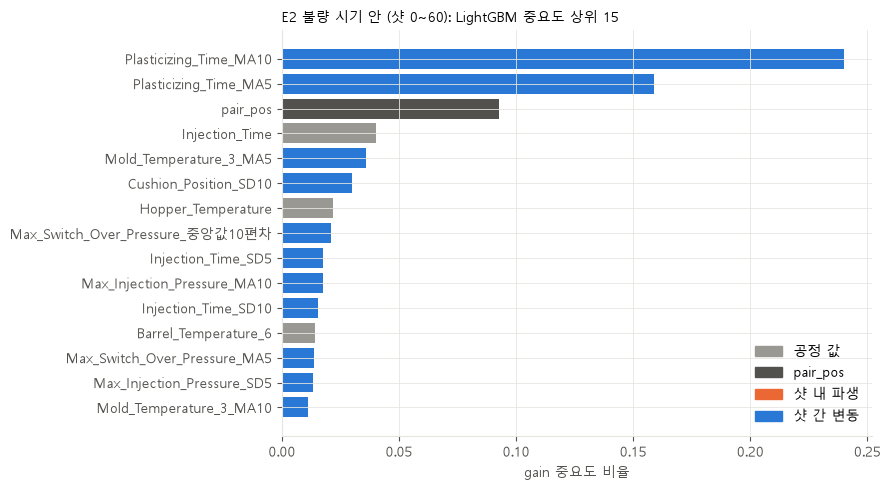

In [12]:
imp_cols = E2_BASES['공정 값 23 + pair_pos'] + DERIVED
y2, g2 = e2[TARGET].values, e2['shot_id'].values
X2 = e2[imp_cols].values.astype(float)
gains = []
for tr, te in mz.make_splits(y2, g2)[:10]:
    m = mz._fit(sup['LightGBM'][0], X2[tr], y2[tr], False)
    gains.append(m.booster_.feature_importance('gain'))
imp = pd.Series(np.mean(gains, axis=0), index=imp_cols)
imp = (imp / imp.sum()).sort_values(ascending=False)
grp = pd.Series({c: '공정 값' if c in feats else ('pair_pos' if c == 'pair_pos' else ('샷 내 파생' if c in WITHIN else '샷 간 변동')) for c in imp_cols})
print('구분별 중요도 합:', imp.groupby(grp).sum().sort_values(ascending=False).round(3).to_dict())
top = imp.head(15)
fig, ax = plt.subplots(figsize=(9, 5))
cmap = {'공정 값': '#9a9893', 'pair_pos': C_INK, '샷 내 파생': C_SUB, '샷 간 변동': C_MAIN}
ax.barh(top.index[::-1], top.values[::-1], color=[cmap[grp[c]] for c in top.index[::-1]])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in cmap.items() if k in set(grp)], frameon=False, loc='lower right')
ax.set_xlabel('gain 중요도 비율')
ax.set_title(f'{E2_NAME}: LightGBM 중요도 상위 15', loc='left')
plt.tight_layout()
plt.savefig(FIGS / 'derived_importance.png', dpi=150, bbox_inches='tight')
plt.show()

→ 중요도의 71%가 샷 간 변동이고, 그중 **가소화 시간 이동평균(MA10·MA5) 두 개가 약 40%**다. 샷 내 파생은 4.5%로 거의 쓰이지 않는다.
→ 모델이 주로 쓰는 신호는 "최근 가소화 시간이 길어졌다"는 추세다. 3장에서 이 변수는 샷 순서와의 상관이 0.55~0.61이었다.

### 4-5. 파생 변수는 시간 흐름의 대리 변수인가

3장에서 신호가 가장 강한 파생 변수는 이동평균(MA)이었고, 샷 순서와의 상관(|ρ|)도 컸다. 파생 변수의 이득이 **샷 순서 정보를 다시 표현한 것**인지 직접 확인한다.
- 같은 fold에서 `1차 피처`에 ① 샷 번호(`shot_id`) ② 파생 전체 ③ 둘 다를 붙여 비교한다.
- 해석: ①과 ②가 비슷하고 ③이 ①보다 거의 오르지 않으면, 파생 변수가 더한 정보는 대부분 시간 흐름이다. ③이 ①보다 뚜렷이 오르면 시간 이외의 정보가 있다.
- 샷 번호는 운영 중 알 수 있는 값이지만 **다른 기간에 일반화되지 않는** 정보라 모델 입력 후보로 쓰지 않는다. 진단용이다.

In [13]:
b = E2_BASES['공정 값 23 + pair_pos']
PROXY = {'1차 피처': b, '+ 샷 번호': b + ['shot_id'], '+ 파생 전체': b + DERIVED, '+ 샷 번호 + 파생 전체': b + ['shot_id'] + DERIVED}
if RUN:
    y2, g2 = e2[TARGET].values, e2['shot_id'].values
    sp2 = mz.make_splits(y2, g2)
    proxy = pd.concat([mz.evaluate_models(MODELS, e2[c].values.astype(float), y2, g2, sp2)[0].assign(features=k) for k, c in PROXY.items()])
    proxy.to_csv(TABLES / 'derived_time_proxy.csv', index=False, encoding='utf-8-sig')
else:
    proxy = pd.read_csv(TABLES / 'derived_time_proxy.csv')
proxy_tbl = proxy.pivot_table(index='model', columns='features', values='PR-AUC', aggfunc='mean').loc[MODEL_NAMES, list(PROXY)]
proxy_tbl.loc['8종 평균'] = proxy_tbl.mean()
print(f'{E2_NAME} — PR-AUC (50 fold 평균), 1차 피처 = 공정 값 23 + pair_pos')
proxy_tbl.round(3)

E2 불량 시기 안 (샷 0~60) — PR-AUC (50 fold 평균), 1차 피처 = 공정 값 23 + pair_pos


features,1차 피처,+ 샷 번호,+ 파생 전체,+ 샷 번호 + 파생 전체
model,,,,
로지스틱 L2,0.642,0.822,0.761,0.778
랜덤포레스트,0.669,0.844,0.806,0.811
엑스트라트리,0.620,0.805,0.862,0.861
GradientBoosting,0.656,0.865,0.806,0.854
HistGradientBoosting,0.617,0.837,0.831,0.840
XGBoost,0.674,0.865,0.840,0.867
LightGBM,0.745,0.884,0.874,0.881
CatBoost,0.663,0.870,0.856,0.859
8종 평균,0.661,0.849,0.829,0.844


→ **파생 변수의 이득은 대부분 시간 흐름이다.** 1차 피처에 샷 번호 하나만 붙여도 8종 평균 PR-AUC가 0.661 → **0.849**로 오른다. 파생 변수 63개를 붙였을 때(0.829)보다 오히려 높다. 둘을 함께 넣으면 0.844로, 샷 번호만 넣은 것과 같다.
→ 즉 파생 변수(특히 이동평균)가 더한 정보는 "지금이 불량 시기의 어느 시점인가"이고, 샷 번호가 이미 가진 정보와 겹친다. CN7은 불량 시기가 한 번뿐이라, 이 추세가 다른 불량 시기에도 통하는지는 이 데이터로 확인할 수 없다.

## 5. 추가 기여 검정 (조건부 순열) — 성공 기준 ②

**5-1. 파생 변수의 추가 기여**: 같은 fold에서 `1차 피처` 모델과 `1차 피처 + 파생 전체` 모델의 PR-AUC 차이를 잰다.
- **조건부 순열**: 샷을 연속 10개씩 묶고, 묶음 안에서만 샷끼리 **파생 변수 값**을 뒤섞는다 (공정 값 23개와 `pair_pos`는 그대로, 같은 샷의 두 부품은 같이 이동). 10샷 단위의 시간 흐름은 남기고 "그 10샷 중 어느 샷이 불량인가"에 대한 파생 변수 정보만 지운 기준이다.
- 실제 추가 기여가 이 기준 분포의 상위 5% 밖이어야(p < 0.05) 파생 변수가 **시간 흐름 이상의** 정보를 더한다고 본다. 이동평균처럼 천천히 변하는 변수는 10샷 창 안에서 섞어도 거의 그대로라, 시간 흐름만 담았다면 기준과 차이가 나지 않는다.
- 검정 모델: 사전 고정 LightGBM · 로지스틱 L2 (1차와 같음) + 4장의 2차 최고 모델(다르면 추가, 사후 선택). 계산량 때문에 1차와 같이 2회 반복(10 fold) × 200번.

**5-2. 샷 순서 대비 기여 (1차 `time_increment`와 같은 방식)**: `샷 순서만` 모델과 `샷 순서 + 공정 값 + 파생 전체` 모델을 비교하고, 10샷 창 안에서 공정 값·파생 변수를 함께 섞어 순열 기준을 만든다 (1차와 같이 `pair_pos` 제외).

In [14]:
def cv_ap(model, X, y, splits):
    out = []
    for tr, te in splits:
        m = mz._fit(model, X[tr], y[tr], False)
        out.append(mz.average_precision_score(y[te], mz._score(m, X[te], False)))
    return np.array(out)


def shuffle_in_windows(ev_e, cols, window, rng):
    """샷을 연속 window개씩 묶고 묶음 안에서 샷끼리 cols 값을 뒤섞는다 (같은 샷의 두 부품은 같이 이동)"""
    shot_vals = ev_e.groupby('shot_id')[cols].first()
    sid = shot_vals.index.values
    new = sid.copy()
    for w0 in range(0, len(sid), window):
        idx = np.arange(w0, min(w0 + window, len(sid)))
        new[idx] = sid[rng.permutation(idx)]
    return shot_vals.loc[new].set_axis(sid).loc[ev_e['shot_id']].values


def increment_test(ev_e, fixed, test, model_name, label, n_perm=200, window=10):
    """fixed 모델 대비 fixed + test 모델의 PR-AUC 추가 기여와 조건부 순열 p (test 열만 창 안에서 섞음)"""
    y, g = ev_e[TARGET].values, ev_e['shot_id'].values
    splits = mz.make_splits(y, g)
    model = sup[model_name][0]
    X0 = ev_e[fixed].values.astype(float)
    ap0 = cv_ap(model, X0, y, splits)
    ap1 = cv_ap(model, ev_e[fixed + test].values.astype(float), y, splits)
    obs = ap1[:10].mean() - ap0[:10].mean()

    def one(seed):
        Xp = np.column_stack([X0, shuffle_in_windows(ev_e, test, window, np.random.default_rng(seed))])
        return cv_ap(model, Xp, y, splits[:10]).mean() - ap0[:10].mean()

    null = np.array(Parallel(n_jobs=-1)(delayed(one)(SEED + i) for i in range(n_perm)))
    row = {'검정': label, '모델': model_name, 'PR-AUC 기준 모델': ap0.mean(), 'PR-AUC 추가 모델': ap1.mean(),
           '추가 기여 (50 fold 평균)': ap1.mean() - ap0.mean(), '추가 기여가 양수인 fold 비율': (ap1 > ap0).mean(),
           '추가 기여 (10 fold)': obs, '순열 기준 평균': null.mean(), '순열 기준 95% 상한': np.quantile(null, 0.95),
           '순열 p': (np.sum(null >= obs) + 1) / (n_perm + 1)}
    return row, null


# 4장의 2차 최고 모델 (파생 변수를 넣은 조합 중 E2 PR-AUC 최고)
cand = summary[(summary['eval'] == E2_NAME) & (summary['family'] != '기준선') & summary['features'].str.contains('파생|변동')]
best = cand.sort_values('PR-AUC_mean', ascending=False).iloc[0]
best_base = next(b for b in E2_BASES if best['features'].startswith(b) and best['features'][len(b):] in ADD)
best_add = best['features'][len(best_base):]
print(f"2차 최고: {best['model']} ({best['features']}) PR-AUC {best['PR-AUC_mean']:.3f} ± {best['PR-AUC_std']:.3f}")

TESTS = [('LightGBM', '공정 값 23 + pair_pos', ' + 파생 전체'), ('로지스틱 L2', '공정 값 23 + pair_pos', ' + 파생 전체')]
if (best['model'], best_base, best_add) not in TESTS:
    TESTS.append((best['model'], best_base, best_add))

if RUN:
    rows, nulls = [], {}
    for m_name, b, a in TESTS:
        t = time.time()
        r, nulls[f'파생 | {m_name} | {b + a}'] = increment_test(e2, E2_BASES[b], ADD[a], m_name, f'5-1 파생 추가 ({b}{a})')
        rows.append(r)
        print(f'5-1 {m_name} {b + a}: {time.time() - t:.0f}s', flush=True)
    for m_name in ['LightGBM', '로지스틱 L2']:
        t = time.time()
        r, nulls[f'시간 | {m_name}'] = increment_test(e2, ['shot_id'], feats + DERIVED, m_name, '5-2 샷 순서 대비 (공정 값 + 파생 전체)')
        rows.append(r)
        print(f'5-2 {m_name}: {time.time() - t:.0f}s', flush=True)
    increment = pd.DataFrame(rows)
    increment.to_csv(TABLES / 'derived_increment.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(nulls).to_csv(TABLES / 'derived_increment_null.csv', index=False, encoding='utf-8-sig')
else:
    increment = pd.read_csv(TABLES / 'derived_increment.csv')
    nulls = pd.read_csv(TABLES / 'derived_increment_null.csv').to_dict('series')
increment.round(3)

2차 최고: LightGBM (공정 값 23 + pair_pos + 파생 전체) PR-AUC 0.874 ± 0.146


,검정,모델,PR-AUC 기준 모델,PR-AUC 추가 모델,추가 기여 (50 fold 평균),추가 기여가 양수인 fold 비율,추가 기여 (10 fold),순열 기준 평균,순열 기준 95% 상한,순열 p
0,5-1 파생 추가 (공정 값 23 + pair_pos + 파생 전체),LightGBM,0.745,0.874,0.129,0.80,0.074,0.034,0.078,0.095
1,5-1 파생 추가 (공정 값 23 + pair_pos + 파생 전체),로지스틱 L2,0.642,0.761,0.119,0.60,0.105,0.077,0.170,0.333
2,5-2 샷 순서 대비 (공정 값 + 파생 전체),LightGBM,0.644,0.671,0.027,0.54,0.041,-0.048,0.014,0.005
3,5-2 샷 순서 대비 (공정 값 + 파생 전체),로지스틱 L2,0.690,0.607,-0.083,0.06,-0.090,-0.171,-0.060,0.119


참고 — 1차 샷 순서 대비 공정 값 23개의 추가 기여 (time_increment.csv):


,PR-AUC 샷 순서만,PR-AUC 샷 순서 + 공정 값,추가 기여 (50 fold 평균),순열 p
모델,,,,
로지스틱 L2,0.690,0.647,-0.043,0.015
LightGBM,0.644,0.670,0.026,0.005


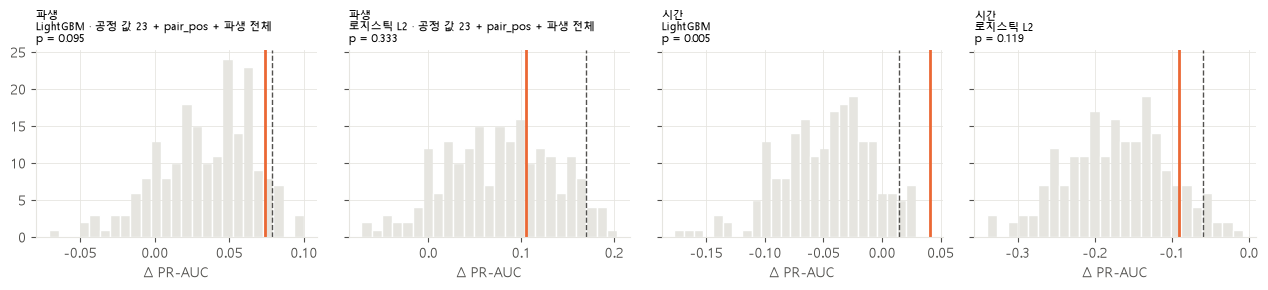

In [15]:
first_inc = pd.read_csv(TABLES / 'time_increment.csv', index_col=0)
print('참고 — 1차 샷 순서 대비 공정 값 23개의 추가 기여 (time_increment.csv):')
display(first_inc[['PR-AUC 샷 순서만', 'PR-AUC 샷 순서 + 공정 값', '추가 기여 (50 fold 평균)', '순열 p']].round(3))

fig, axes = plt.subplots(1, len(nulls), figsize=(3.2 * len(nulls), 3), sharey=True)
for ax, (k, null) in zip(np.atleast_1d(axes), nulls.items()):
    r = increment.iloc[list(nulls).index(k)]
    ax.hist(np.asarray(null), bins=25, color=C_GRID, edgecolor='white')
    ax.axvline(r['추가 기여 (10 fold)'], color=C_SUB, linewidth=2)
    ax.axvline(r['순열 기준 95% 상한'], color=C_INK, linestyle='--', linewidth=1)
    ax.set_title(k.replace(' | ', '\n', 1).replace(' | ', ' · ') + f"\np = {r['순열 p']:.3f}", loc='left', fontsize=8)
    ax.set_xlabel('Δ PR-AUC')
plt.tight_layout()
plt.savefig(FIGS / 'derived_permutation.png', dpi=150, bbox_inches='tight')
plt.show()

- **5-1 파생 추가 (기준 ②)**: LightGBM의 추가 기여 +0.074(10 fold)는 순열 기준의 95% 상한(+0.078)을 넘지 못한다 (**p = 0.095**). 순열 기준은 10샷 창 안에서 파생 변수를 섞은 것이다. 섞은 파생 변수로도 평균 +0.034가 나오는데, 창 안에서 섞어도 이동평균은 거의 그대로라 시간 흐름 정보가 남기 때문이다. 로지스틱도 p = 0.33이다.
- **5-2 샷 순서 대비**: LightGBM에서 `샷 순서 + 공정 값 + 파생 전체`는 `샷 순서만`보다 +0.027 높다 (p = 0.005). 1차의 `샷 순서 + 공정 값 23`(+0.026, p = 0.005)과 사실상 같다 → **시간을 통제하면 파생 변수는 1차 공정 값에 더하는 것이 없다.**

## 6. 판정 (보고서 표 6)

- **기준 ①**: 2차 최고 모델의 E2 PR-AUC − 비교 대상 ≥ 2차 최고 모델의 fold 간 표준편차 (1차 판정 때 "무작위와의 차이가 fold 간 표준편차 안"이라고 본 것과 같은 방식). 비교 대상 = 기준선 = **샷 순서** (0.766 ± 0.184), 1차 최고 = **LightGBM (공정 값 + pair_pos)** (0.745 ± 0.201)
  - 보조로, 같은 fold끼리 짝지은 차이(Δ)의 평균이 Δ의 표준편차보다 큰지도 함께 적는다 (짝지은 비교는 fold 난이도 차이가 빠져 더 민감하다).
- **기준 ②**: 5-1에서 2차 최고 모델의 파생 변수 추가 기여 순열 p < 0.05
- 두 기준을 모두 넘어야 **성공**이다.

In [16]:
first_model, first_feat, first_mean, first_std = ('LightGBM', '공정 값 23 + pair_pos', 0.745, 0.201)
e2f = folds[folds['eval'] == E2_NAME]
best_folds = e2f[(e2f['model'] == best['model']) & (e2f['features'] == best['features'])].set_index('fold')['PR-AUC']
base_folds = e2f[e2f['model'] == '[기준] 샷 순서'].set_index('fold')['PR-AUC']
first_folds = e2f[(e2f['model'] == first_model) & (e2f['features'] == first_feat)].set_index('fold')['PR-AUC']
sd = best['PR-AUC_std']
p_best = increment[(increment['모델'] == best['model']) & increment['검정'].str.contains(best['features'], regex=False)]['순열 p'].iloc[0]

rows = []
for name, ref in [('[기준] 샷 순서'.replace('[기준] ', '기준선: '), base_folds), (f'1차 최고: {first_model} ({first_feat})', first_folds)]:
    d = (best_folds - ref).dropna()
    rows.append({'비교 대상': name, '비교 대상 PR-AUC': ref.mean(), '2차 최고 PR-AUC': best_folds.mean(), '차이': best_folds.mean() - ref.mean(),
                 '2차 최고 fold 표준편차': sd, '① 통과 (차이 ≥ 표준편차)': best_folds.mean() - ref.mean() >= sd,
                 '보조: 짝지은 Δ 평균 / 표준편차': f'{d.mean():+.3f} / {d.std():.3f}', '보조: 개선 fold 비율': (d > 0).mean()})
crit = pd.DataFrame(rows)
display(crit.round(3))
ok1 = bool(crit['① 통과 (차이 ≥ 표준편차)'].all())
ok2 = p_best < 0.05
print(f"기준 ①: {'통과' if ok1 else '미달'} | 기준 ② (5-1 {best['model']} p = {p_best:.3f}): {'통과' if ok2 else '미달'}")
print('판정:', '성공' if ok1 and ok2 else '실패')

table6 = pd.DataFrame([{'제품': 'CN7', '1차 최고 PR-AUC': f'{first_mean:.3f} ± {first_std:.3f} ({first_model})',
                        '2차 최고 모델': f"{best['model']} ({best['features']})",
                        '2차 PR-AUC': f"{best['PR-AUC_mean']:.3f} ± {best['PR-AUC_std']:.3f}",
                        '조건부 순열 p': f'{p_best:.3f}', '판정': '성공' if ok1 and ok2 else '실패'}])
table6.to_csv(TABLES / 'derived_table6.csv', index=False, encoding='utf-8-sig')
table6

,비교 대상,비교 대상 PR-AUC,2차 최고 PR-AUC,차이,2차 최고 fold 표준편차,① 통과 (차이 ≥ 표준편차),보조: 짝지은 Δ 평균 / 표준편차,보조: 개선 fold 비율
0,기준선: 샷 순서,0.766,0.874,0.108,0.146,False,+0.108 / 0.129,0.78
1,1차 최고: LightGBM (공정 값 23 + pair_pos),0.745,0.874,0.129,0.146,False,+0.129 / 0.179,0.80


기준 ①: 미달 | 기준 ② (5-1 LightGBM p = 0.095): 미달
판정: 실패


,제품,1차 최고 PR-AUC,2차 최고 모델,2차 PR-AUC,조건부 순열 p,판정
0,CN7,0.745 ± 0.201 (LightGBM),LightGBM (공정 값 23 + pair_pos + 파생 전체),0.874 ± 0.146,0.095,실패


→ **2차 판정: 실패**
- 기준 ① 미달: 최고 모델(LightGBM, 공정 값 + pair_pos + 파생 전체)은 평균으로는 샷 순서보다 +0.108, 1차 최고보다 +0.129 높다. 하지만 두 차이 모두 fold 간 표준편차(0.146)보다 작다. 같은 fold끼리 짝지어 비교해도 Δ 평균이 Δ 표준편차보다 작다.
- 기준 ② 미달: 조건부 순열 p = 0.095 ≥ 0.05
- 이 최고 모델은 파생 변수를 넣은 24개 조합(8개 모델 × 3) 중 결과를 보고 고른 것이라 실제보다 낙관적이다.

## 7. 결론과 5단계 연결

**2차 시도 결과 (보고서 표 6)**

| 제품 | 1차 최고 PR-AUC | 2차 최고 모델 | 2차 PR-AUC | 조건부 순열 p | 판정 |
|---|---|---|---|---|---|
| CN7 | 0.745 ± 0.201 (LightGBM) | LightGBM (공정 값 + pair_pos + 파생 전체) | 0.874 ± 0.146 | 0.095 | **실패** |

1. **샷 간 변동(이동평균)은 PR-AUC를 크게 올렸지만, 그 정보는 샷 번호 하나로 얻는 것과 같은 시간 흐름이었다** (4-5: 샷 번호만 0.849 vs 파생 전체 0.829, 5-2: 샷 순서 대비 추가 기여 1차와 동일). 시간을 통제하면 추가 정보가 없다.
2. **샷 내 파생(압력 지표·시간 구성·계량·온도 구배)은 모든 모델에서 성능을 낮췄다.** 데이터가 표준화된 z값이라 논문의 비율 지표를 만들 수 없었고, 차이는 기존 값의 선형 결합이라 새 정보가 없다.
3. 손익 분석용 검사율@재현율0.9는 1차보다 나빠졌다 (38% → 54%, 샷 순서 29%).

→ 성공 기준 ①·② 모두 미달 → **5단계는 "2차 실패" 경로로 간다.**

**5단계 연결 (보고서 제4장)**
- **현재 운영안 유지**: 쌍 순서 규칙(앞쪽 부품 우선, 검사 50%로 불량 76%). 보고서 표 9 그대로다.
- **센서 도입 판단**: 공정 스칼라 값 23개와 그 파생 변수로는 시간 흐름 이상의 부품별 정보를 얻지 못했다. 캐비티별 금형 내압 센서 도입 여부를 손익분기점 분석으로 판단한다. 손익 계산의 검사율은 1차 E2 값(재현율 0.9에 38%)을 보수적 기준으로 유지한다. 2차 모델은 이 값을 개선하지 못했다.
- **현장 감시 지표 후보 (가설)**: 불량 시기에는 가소화 시간과 금형 온도 3의 **최근 이동평균이 오르는 추세**가 있었다 (3장, 4-4). 불량 시기를 알리는 경보 지표로 쓸 수 있지만, 불량 시기가 한 번뿐이라 여러 기간의 라벨 데이터로 검증해야 한다.

**보고서 반영 위치**
- 표 6: 위 표 (`outputs/tables/derived_table6.csv`)
- 제2장 4·5단계: 4-2 표·그림 (`outputs/figures/derived_prauc.png`), 5장 순열검정 (`derived_increment.csv`, `outputs/figures/derived_permutation.png`)
- 제3장 영향요인: 3장 단변량 표 (`derived_univariate.csv`), 4-4 중요도 (`outputs/figures/derived_importance.png`), 4-5 시간 대리 확인 (`derived_time_proxy.csv`)
- 제4장 "2차 성공 시 예상 검사율": 해당 없음 (2차 실패)
- 표 11 "2차 시도(파생 변수) 코드": `CN71.ipynb` — 결과표 `outputs/tables/derived_*.csv`, 그림 `outputs/figures/derived_*.png`